C:\Users\lucap\AppData\Local\Temp\ipykernel_23980\121219709.py:9: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


Analizando traza: 109C.TA_20060723155859_EV
Muestra de llegada Onda P (Inicio sismo): 700.0
Muestra de llegada Onda S (Pico destructivo): 1894.0
Extrayendo matriz de señales del HDF5...


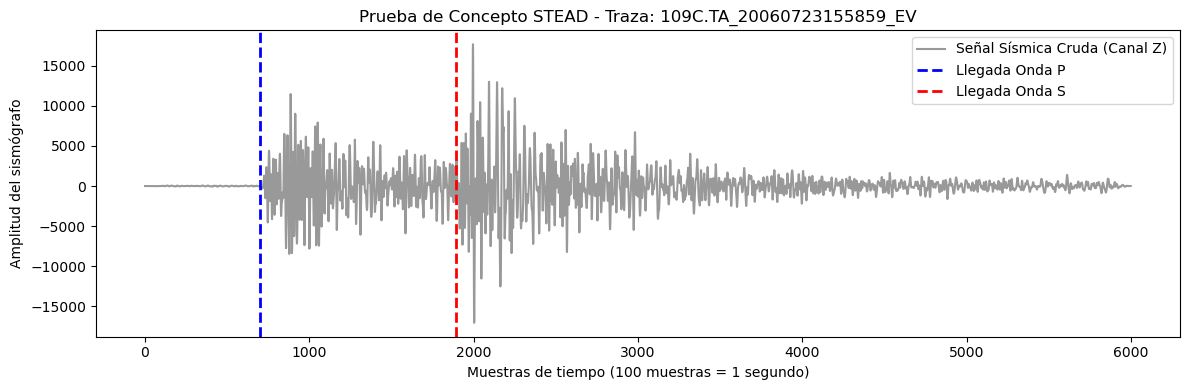

In [2]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np

csv_file = '../data/raw/chunk2.csv'
hdf5_file = '../data/raw/chunk2.hdf5'

df = pd.read_csv(csv_file)

# Filtramos buscando un evento que sea un sismo local y de magnitud > 3 
# Para garantizar que el pico destructivo sea obvio a simple vista
df_earthquake = df[(df.trace_category == 'earthquake_local') & (df.source_magnitude > 3)]

# Tomamos el primer resultado que cumpla la condición
trace_name = df_earthquake['trace_name'].iloc[0]
p_arrival_sample = df_earthquake['p_arrival_sample'].iloc[0]
s_arrival_sample = df_earthquake['s_arrival_sample'].iloc[0]

print(f"Analizando traza: {trace_name}")
print(f"Muestra de llegada Onda P (Inicio sismo): {p_arrival_sample}")
print(f"Muestra de llegada Onda S (Pico destructivo): {s_arrival_sample}")

# Extraer la señal cruda del archivo HDF5
print("Extrayendo matriz de señales del HDF5...")
with h5py.File(hdf5_file, 'r') as dtfl:
    # STEAD guarda los arrays dentro del grupo 'data' usando el trace_name
    dataset = dtfl.get('data/' + trace_name)
    data = np.array(dataset)

# El array de STEAD tiene dimensiones (6000, 3) que son 60 segundos a 100Hz.
# Los canales son: 0 (Este-Oeste), 1 (Norte-Sur), 2 (Vertical / Z).
# Extraemos el canal vertical para la visualización.
canal_z = data[:, 2]

# Graficar la señal
plt.figure(figsize=(12, 4))
plt.plot(canal_z, color='gray', alpha=0.8, label='Señal Sísmica Cruda (Canal Z)')

# Dibujar líneas verticales exactamente donde el sismólogo humano marcó las ondas
plt.axvline(x=p_arrival_sample, color='blue', linestyle='--', linewidth=2, label='Llegada Onda P')
if not np.isnan(s_arrival_sample):
    plt.axvline(x=s_arrival_sample, color='red', linestyle='--', linewidth=2, label='Llegada Onda S')

# Detalles del gráfico
plt.title(f"Prueba de Concepto STEAD - Traza: {trace_name}")
plt.xlabel("Muestras de tiempo (100 muestras = 1 segundo)")
plt.ylabel("Amplitud del sismógrafo")
plt.legend()
plt.tight_layout()
plt.show()